## Import Required Libraries

Load all libraries required for video processing, numerical computations, visualization, signal processing, and clustering.

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from matplotlib.patches import Rectangle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load Video Dataset

Load all slot gameplay videos that will be used throughout the dynamic analysis.

In [2]:
video_dir = Path("../data/videos")
videos = sorted(video_dir.glob("*.mp4"))

len(videos), videos[:3]

(81,
 [WindowsPath('../data/videos/video_id (1).mp4'),
  WindowsPath('../data/videos/video_id (10).mp4'),
  WindowsPath('../data/videos/video_id (11).mp4')])

## Open the First Video

Open one video from the dataset and verify that it can be accessed successfully before starting the analysis.

In [3]:
video_path = str(videos[0])
cap = cv2.VideoCapture(video_path)

cap.isOpened()

True

## Check the First Video Frame

Read the first frame from the selected video and verify that the video is decoded correctly before continuing the analysis.

In [4]:
ret, frame = cap.read()
ret, frame.shape

(True, (1080, 1920, 3))

## Release Video Resources

Close the video file after the initial verification to free system resources.

In [5]:
cap.release()

## Display Two Consecutive Frames

Read two consecutive frames from the video and display them to visually inspect how the slot changes over time.

In [6]:
video_path = str(videos[0])
cap = cv2.VideoCapture(video_path)

ok1, frame1 = cap.read()
ok2, frame2 = cap.read()

cap.release()

ok1, ok2, frame1.shape

(True, True, (1080, 1920, 3))

## Convert Frames to RGB for Visualization

Convert OpenCV BGR images into RGB format so that Matplotlib displays the correct colors.

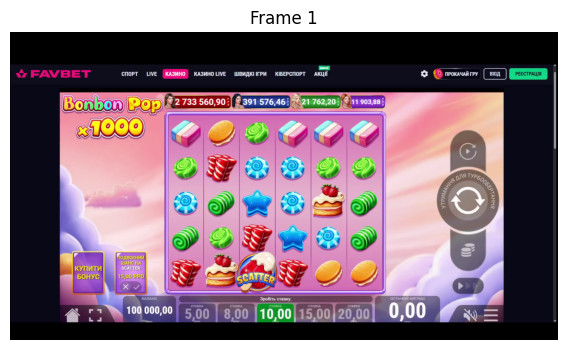

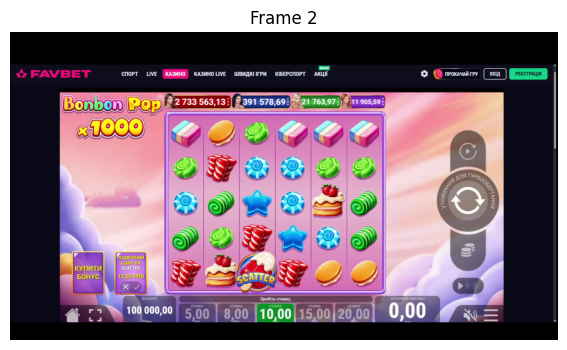

In [7]:
frame1_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
frame2_rgb = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,4))
plt.imshow(frame1_rgb)
plt.title("Frame 1")
plt.axis("off")
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(frame2_rgb)
plt.title("Frame 2")
plt.axis("off")
plt.show()

# Compare Two Frames After Time Skip

Skip approximately 100 frames and read two distant moments from the video instead of consecutive frames.

In [8]:
cap = cv2.VideoCapture(video_path)

ret1, frame_a = cap.read()

for _ in range(100):
    cap.read()

ret2, frame_b = cap.read()

cap.release()

ret1, ret2, frame_a.shape

(True, True, (1080, 1920, 3))

# Calculate the Difference Between Two Frames

Convert both frames to grayscale and calculate their absolute pixel difference.

The mean and maximum values provide a simple numerical estimate of how strongly the scene changed.

In [9]:
g_a = cv2.cvtColor(frame_a, cv2.COLOR_BGR2GRAY)
g_b = cv2.cvtColor(frame_b, cv2.COLOR_BGR2GRAY)

diff = cv2.absdiff(g_b, g_a)

mean_diff = float(diff.mean())
max_diff = int(diff.max())

mean_diff, max_diff

(1.5409307484567902, 213)

# Visualize the Frame Difference

Display the difference map to see which screen regions changed between the two selected moments.

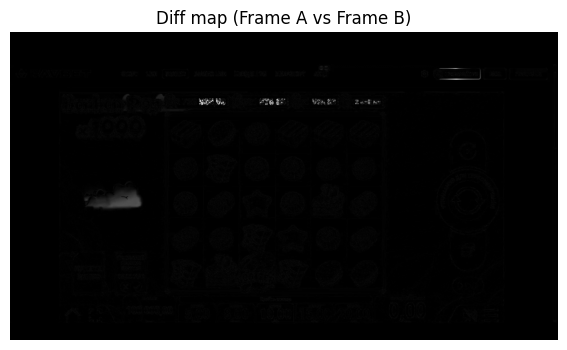

In [10]:
plt.figure(figsize=(10,4))
plt.imshow(diff, cmap="gray")
plt.title("Diff map (Frame A vs Frame B)")
plt.axis("off")
plt.show()


# Measure Temporal Activity

Sample one frame approximately every second and calculate the average pixel difference between consecutive samples.

This creates a time series showing how the amount of motion changes throughout the video.

In [11]:
video_path = str(videos[0])
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)          
step = int(round(fps)) if fps > 0 else 30 

activity_per_sec = []   
times_sec = []         

ret, prev = cap.read()
if not ret:
    cap.release()
    raise ValueError("Failed to read the first frame")

prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

t = 0  

while True:
    for _ in range(step - 1):
        ret = cap.grab()   
        if not ret:
            break
    if not ret:
        break

    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(gray, prev_gray)

    activity_per_sec.append(float(diff.mean()))
    times_sec.append(t + 1)

    prev_gray = gray
    t += 1

cap.release()

len(activity_per_sec), activity_per_sec[:5]

(40,
 [1.406000675154321,
  0.6317872299382716,
  0.543422550154321,
  8.78449893904321,
  9.026223958333333])

# Visualize Activity Over Time

Plot the temporal activity curve to observe when the slot is relatively stable and when strong visual changes occur.

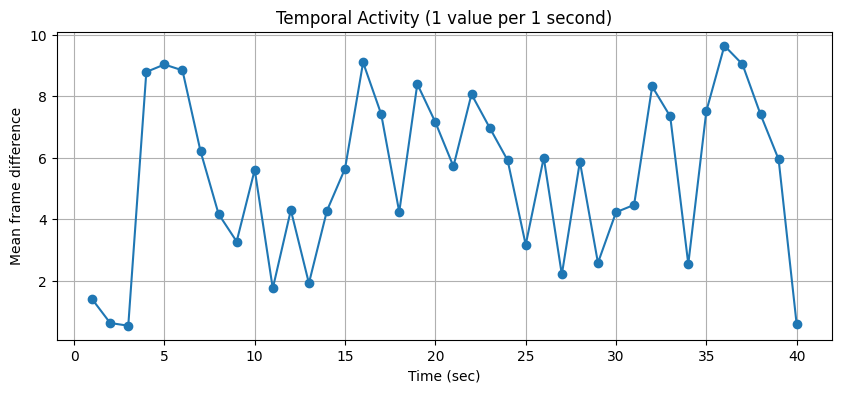

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(times_sec, activity_per_sec, marker="o")
plt.title("Temporal Activity (1 value per 1 second)")
plt.xlabel("Time (sec)")
plt.ylabel("Mean frame difference")
plt.grid(True)
plt.show()

## Measure Temporal Activity

Sample one frame every second and calculate the average pixel difference between consecutive frames. This creates a simple time series describing how much the slot changes over time.

In [13]:
grid = 6

video_path = str(videos[0])
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
step = int(round(fps)) if fps > 0 else 30

ret, frame_a = cap.read()
if not ret:
    cap.release()
    raise ValueError("Failed to read the first frame")

skip_frames = 100
for _ in range(skip_frames):
    ret = cap.grab()
    if not ret:
        break

ret, frame_b = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read the frame after skipping")

g_a = cv2.cvtColor(frame_a, cv2.COLOR_BGR2GRAY)
g_b = cv2.cvtColor(frame_b, cv2.COLOR_BGR2GRAY)
diff = cv2.absdiff(g_b, g_a).astype(np.float32)

h, w = diff.shape
cell_h = h // grid
cell_w = w // grid

grid_means = np.zeros((grid, grid), dtype=np.float32)

for i in range(grid):
    for j in range(grid):
        y0 = i * cell_h
        y1 = (i + 1) * cell_h
        x0 = j * cell_w
        x1 = (j + 1) * cell_w

        cell = diff[y0:y1, x0:x1]
        grid_means[i, j] = cell.mean()

grid_means

array([[0.28512153, 0.33953124, 0.4619271 , 0.41168404, 1.4490452 ,
        0.96321183],
       [1.0649652 , 2.9079688 , 5.619462  , 3.7622223 , 1.0822396 ,
        0.47833332],
       [0.395625  , 1.1084201 , 1.7965972 , 1.7853298 , 0.96802086,
        0.6130555 ],
       [1.5332986 , 7.180625  , 1.8375174 , 2.2512152 , 1.016441  ,
        0.7107639 ],
       [0.86609375, 2.0172222 , 2.7579515 , 2.100868  , 0.9331076 ,
        0.5736806 ],
       [0.4863368 , 1.27625   , 1.3923091 , 1.3259201 , 1.1243576 ,
        0.59678817]], dtype=float32)

# Divide the Screen into a 6×6 Grid

Split the frame difference into equal spatial regions and calculate the average motion inside each cell.

This creates a coarse spatial representation of where movement occurs on the screen.

In [14]:
grid = 6
video_path = str(videos[0])

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
step = int(round(fps)) if fps and fps > 0 else 30  

ret, prev_frame = cap.read()
if not ret:
    cap.release()
    raise ValueError("Failed to read the first frame")

prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

h, w = prev_gray.shape
cell_h = h // grid
cell_w = w // grid

grid_sum = np.zeros((grid, grid), dtype=np.float64)
count = 0

while True:
    ok = True
    for _ in range(step - 1):
        if not cap.grab():
            ok = False
            break
    if not ok:
        break

    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(gray, prev_gray).astype(np.float32)

    grid_means = np.zeros((grid, grid), dtype=np.float32)
    for i in range(grid):
        for j in range(grid):
            y0, y1 = i * cell_h, (i + 1) * cell_h
            x0, x1 = j * cell_w, (j + 1) * cell_w
            grid_means[i, j] = diff[y0:y1, x0:x1].mean()

    grid_sum += grid_means
    count += 1

    prev_gray = gray

cap.release()

grid_avg = (grid_sum / max(count, 1)).astype(np.float32)

count, grid_avg

(40,
 array([[ 0.04294227,  0.04924392,  0.06374653,  0.15753733,  0.9364757 ,
          0.56369096],
        [ 0.19297917,  2.3517857 ,  9.320216  ,  9.261404  ,  0.9515165 ,
          0.28111112],
        [ 0.23886155,  6.243443  , 17.865444  , 18.45792   ,  2.3120973 ,
          1.9423494 ],
        [ 0.15506424,  6.3408103 , 18.55829   , 22.129671  ,  6.2746096 ,
          6.53285   ],
        [ 3.979451  , 11.9578285 , 16.599813  , 18.834463  ,  2.0680273 ,
          1.2980647 ],
        [ 0.54065233,  1.4210265 ,  2.3896644 ,  1.8432509 ,  2.3176024 ,
          0.11290972]], dtype=float32))

# Average Motion Heatmap

Visualize the average amount of motion measured in every cell of the 6×6 grid.

The heatmap reveals which parts of the slot interface are the most active during the recording.

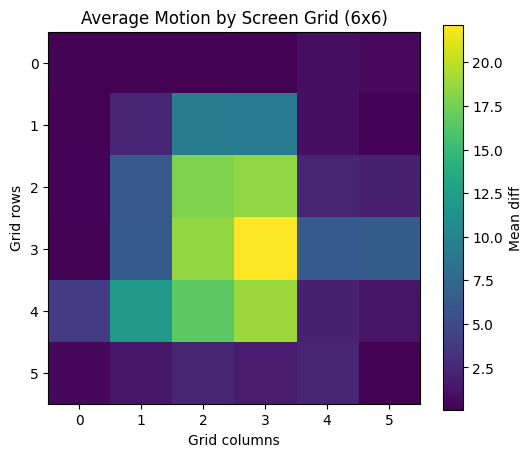

In [15]:
plt.figure(figsize=(6, 5))
plt.imshow(grid_avg, interpolation="nearest")
plt.title("Average Motion by Screen Grid (6x6)")
plt.xlabel("Grid columns")
plt.ylabel("Grid rows")
plt.colorbar(label="Mean diff")
plt.show()

# Compute Average Motion Across the Entire Video

Process the complete recording and accumulate motion values for every grid cell.

The result summarizes where motion usually occurs throughout the video.

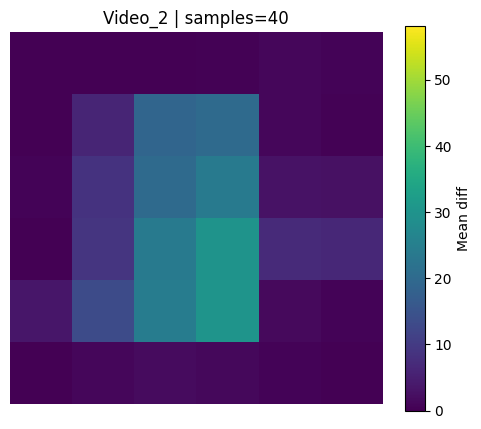

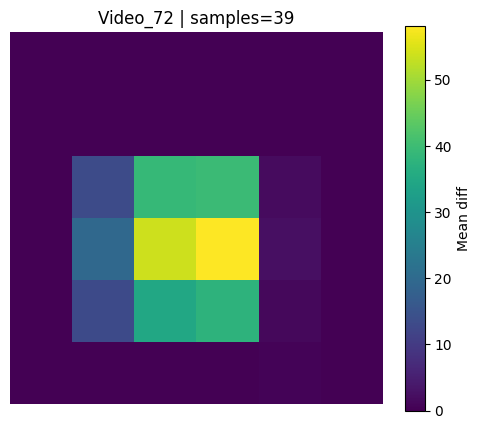

('max002', 30.007125854492188, 'max072', 58.18191146850586)

In [16]:
grid = 6
skip_start_frames = 100  

def find_video_by_id(videos, vid_id_str):
    for p in videos:
        name = p.stem
        if vid_id_str in name:
            return str(p)
    raise ValueError(f"No video found with an ID containing: {vid_id_str}")

def grid_avg_for_video(video_path, grid=6, skip_start_frames=100):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    step = int(round(fps)) if fps and fps > 0 else 30  

    ret, first = cap.read()
    if not ret:
        cap.release()
        raise ValueError(f"Failed to read the first frame: {video_path}")

    for _ in range(skip_start_frames):
        if not cap.grab():
            break

    ret, prev_frame = cap.read()
    if not ret:
        cap.release()
        raise ValueError(f"Failed to read the frame after skipping: {video_path}")

    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

    h, w = prev_gray.shape
    cell_h = h // grid
    cell_w = w // grid

    grid_sum = np.zeros((grid, grid), dtype=np.float64)
    count = 0

    while True:
        ok = True
        for _ in range(step - 1):
            if not cap.grab():
                ok = False
                break
        if not ok:
            break

        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(gray, prev_gray).astype(np.float32)

        grid_means = np.zeros((grid, grid), dtype=np.float32)
        for i in range(grid):
            for j in range(grid):
                y0, y1 = i * cell_h, (i + 1) * cell_h
                x0, x1 = j * cell_w, (j + 1) * cell_w
                grid_means[i, j] = diff[y0:y1, x0:x1].mean()

        grid_sum += grid_means
        count += 1
        prev_gray = gray

    cap.release()
    grid_avg = (grid_sum / max(count, 1)).astype(np.float32)
    return grid_avg, count

video_2 = find_video_by_id(videos, "2")
video_72 = find_video_by_id(videos, "72")

g002, c002 = grid_avg_for_video(video_2, grid=grid, skip_start_frames=skip_start_frames)
g072, c072 = grid_avg_for_video(video_72, grid=grid, skip_start_frames=skip_start_frames)

vmax = float(max(g002.max(), g072.max()))

plt.figure(figsize=(6, 5))
plt.imshow(g002, interpolation="nearest", vmin=0, vmax=vmax)
plt.title(f"Video_2 | samples={c002}")
plt.colorbar(label="Mean diff")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(g072, interpolation="nearest", vmin=0, vmax=vmax)
plt.title(f"Video_72 | samples={c072}")
plt.colorbar(label="Mean diff")
plt.axis("off")
plt.show()

("max002", float(g002.max()), "max072", float(g072.max()))

# Summarize Grid Statistics

Compute several summary statistics describing the overall motion distribution across the screen.

These metrics help compare different gameplay recordings using a compact numerical representation.

In [17]:
def summarize_grid(G):
    G = np.array(G, dtype=np.float32)
    overall_mean = float(G.mean())
    overall_max = float(G.max())

    center = G[2:4, 2:4]
    center_mean = float(center.mean())

    border_mask = np.ones_like(G, dtype=bool)
    border_mask[1:-1, 1:-1] = False
    border_mean = float(G[border_mask].mean())

    cv = float(G.std() / (G.mean() + 1e-6))

    return {
        "overall_mean": overall_mean,
        "overall_max": overall_max,
        "center_mean": center_mean,
        "border_mean": border_mean,
        "center_to_border": float(center_mean / (border_mean + 1e-6)),
        "cv": cv
    }

s002 = summarize_grid(g002)
s072 = summarize_grid(g072)

s002, s072

({'overall_mean': 7.273460388183594,
  'overall_max': 30.007125854492188,
  'center_mean': 24.478351593017578,
  'border_mean': 1.0687320232391357,
  'center_to_border': 22.904084613038474,
  'cv': 1.316118597984314},
 {'overall_mean': 8.792757987976074,
  'overall_max': 58.18191146850586,
  'center_mean': 47.648902893066406,
  'border_mean': 0.09290479868650436,
  'center_to_border': 512.8732928054355,
  'cv': 1.8920842409133911})

# Compute Motion Statistics for Every Grid Cell

Process the entire recording and compute motion statistics for every cell of the 6×6 grid.

For each location we calculate:
- Mean motion
- Standard deviation
- Coefficient of variation (CV)

These maps describe both the intensity and the stability of motion.

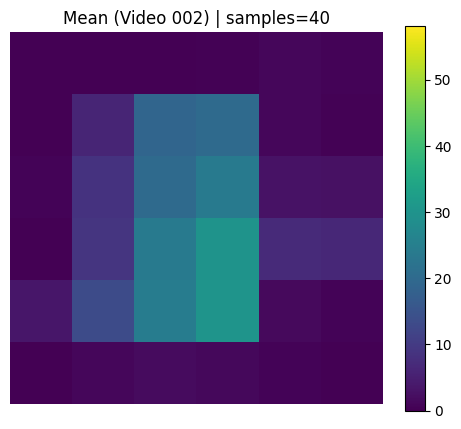

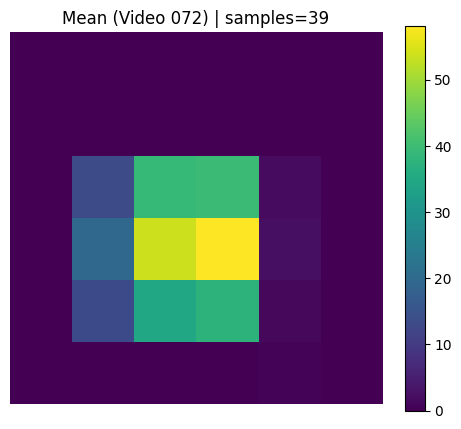

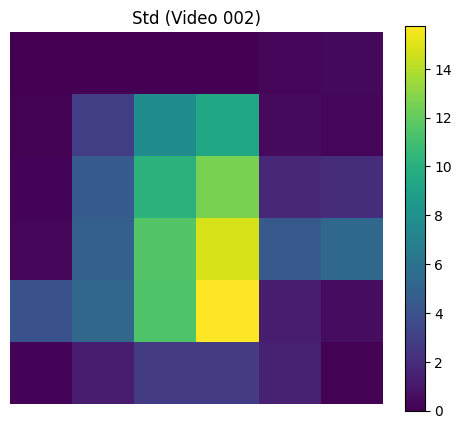

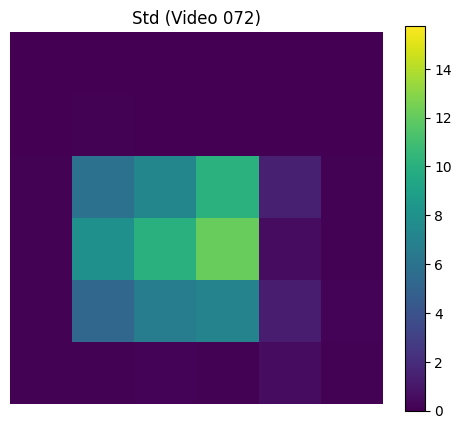

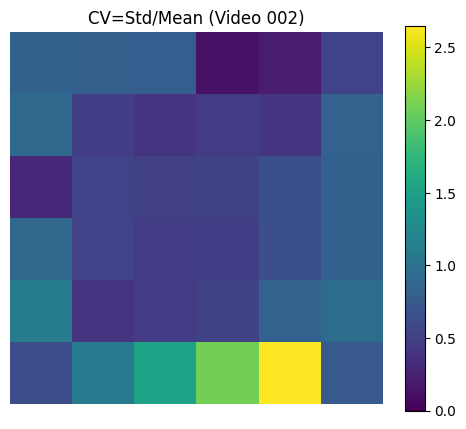

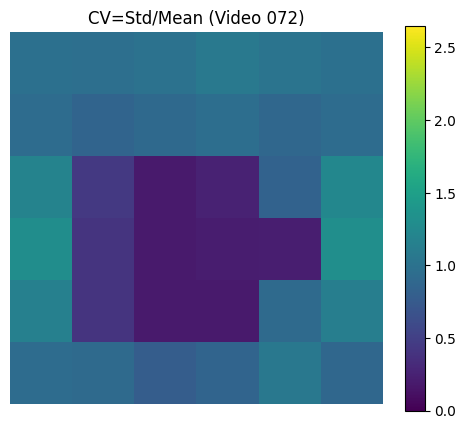

('mean_max_002',
 30.007125854492188,
 'std_max_002',
 15.773211479187012,
 'cv_max_002',
 2.6511967182159424,
 'mean_max_072',
 58.18191146850586,
 'std_max_072',
 12.09962272644043,
 'cv_max_072',
 1.3126797676086426)

In [18]:
grid = 6
skip_start_frames = 100  

def per_cell_stats(video_path, grid=6, skip_start_frames=100):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    step = int(round(fps)) if fps and fps > 0 else 30  

    ret, _ = cap.read()
    if not ret:
        cap.release()
        raise ValueError(f"Failed to read the first frame: {video_path}")

    for _ in range(skip_start_frames):
        if not cap.grab():
            break

    ret, prev_frame = cap.read()
    if not ret:
        cap.release()
        raise ValueError(f"Failed to read the frame after skipping: {video_path}")

    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    h, w = prev_gray.shape
    cell_h = h // grid
    cell_w = w // grid

    sum_grid = np.zeros((grid, grid), dtype=np.float64)
    sumsq_grid = np.zeros((grid, grid), dtype=np.float64)
    count = 0

    while True:
        ok = True
        for _ in range(step - 1):
            if not cap.grab():
                ok = False
                break
        if not ok:
            break

        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(gray, prev_gray).astype(np.float32)

        grid_means = np.zeros((grid, grid), dtype=np.float32)
        for i in range(grid):
            for j in range(grid):
                y0, y1 = i * cell_h, (i + 1) * cell_h
                x0, x1 = j * cell_w, (j + 1) * cell_w
                grid_means[i, j] = diff[y0:y1, x0:x1].mean()

        sum_grid += grid_means
        sumsq_grid += grid_means ** 2
        count += 1
        prev_gray = gray

    cap.release()

    mean_grid = (sum_grid / max(count, 1)).astype(np.float32)
    ex2 = (sumsq_grid / max(count, 1)).astype(np.float32)
    var_grid = np.maximum(ex2 - mean_grid**2, 0.0).astype(np.float32)
    std_grid = np.sqrt(var_grid).astype(np.float32)
    cv_grid = (std_grid / (mean_grid + 1e-6)).astype(np.float32)

    return count, mean_grid, std_grid, cv_grid

c002, mean002, std002, cv002 = per_cell_stats(video_2, grid=grid, skip_start_frames=skip_start_frames)
c072, mean072, std072, cv072 = per_cell_stats(video_72, grid=grid, skip_start_frames=skip_start_frames)

vmax_mean = float(max(mean002.max(), mean072.max()))
vmax_std = float(max(std002.max(), std072.max()))
vmax_cv = float(max(cv002.max(), cv072.max()))

def show_pair(A, B, titleA, titleB, vmax):
    plt.figure(figsize=(6,5))
    plt.imshow(A, interpolation="nearest", vmin=0, vmax=vmax)
    plt.title(titleA)
    plt.colorbar()
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6,5))
    plt.imshow(B, interpolation="nearest", vmin=0, vmax=vmax)
    plt.title(titleB)
    plt.colorbar()
    plt.axis("off")
    plt.show()

show_pair(mean002, mean072, f"Mean (Video 002) | samples={c002}", f"Mean (Video 072) | samples={c072}", vmax_mean)
show_pair(std002,  std072,  "Std (Video 002)",             "Std (Video 072)",             vmax_std)
show_pair(cv002,   cv072,   "CV=Std/Mean (Video 002)",     "CV=Std/Mean (Video 072)",     vmax_cv)

("mean_max_002", float(mean002.max()), "std_max_002", float(std002.max()), "cv_max_002", float(cv002.max()),
 "mean_max_072", float(mean072.max()), "std_max_072", float(std072.max()), "cv_max_072", float(cv072.max()))

# Compare Motion Statistics Between Two Videos

Display the mean, standard deviation and coefficient of variation maps for two gameplay recordings.

A shared color scale allows direct visual comparison.

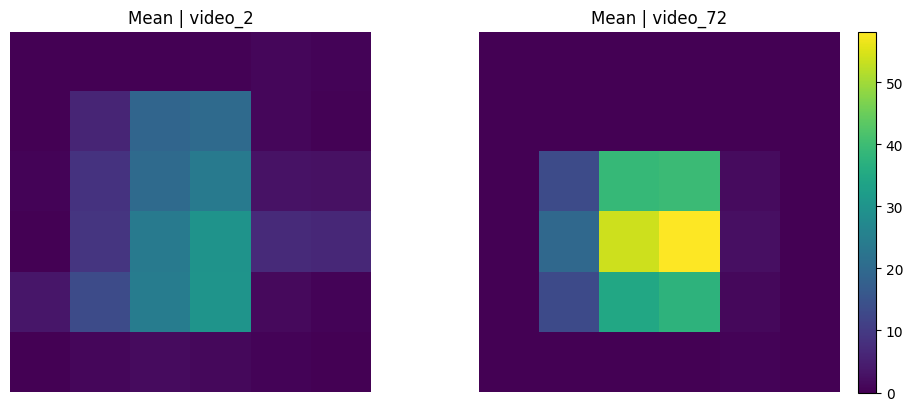

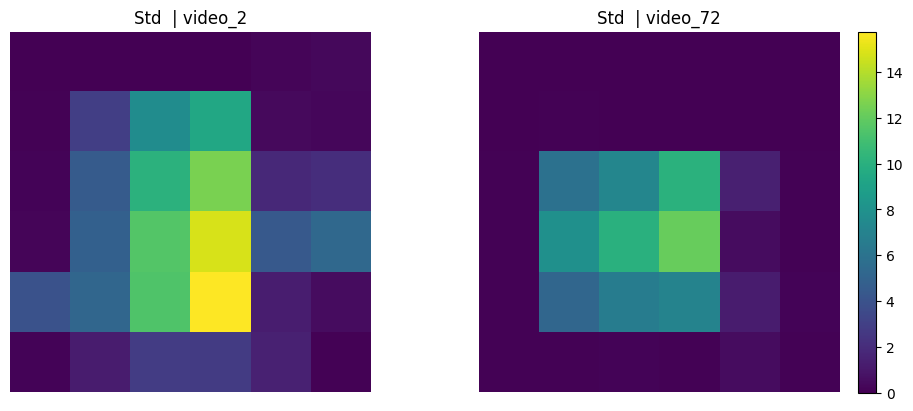

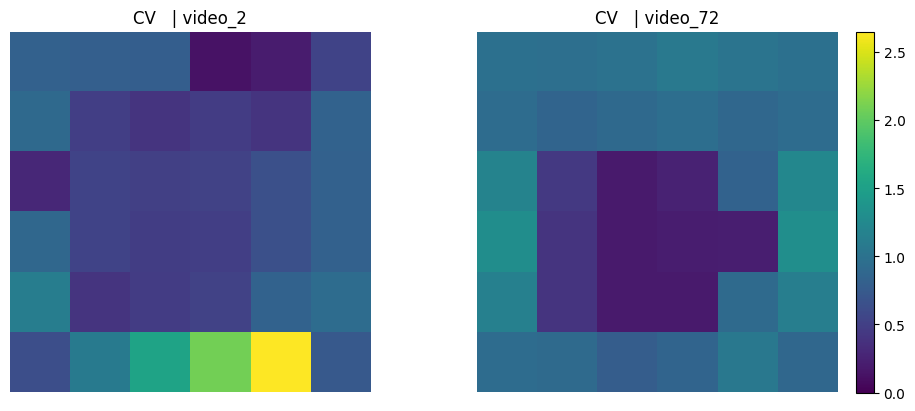

In [19]:
def show_row(A_left, A_right, title_left, title_right, vmax):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    im = ax[0].imshow(A_left, vmin=0, vmax=vmax, interpolation="nearest")
    ax[0].set_title(title_left)
    ax[0].axis("off")

    ax[1].imshow(A_right, vmin=0, vmax=vmax, interpolation="nearest")
    ax[1].set_title(title_right)
    ax[1].axis("off")

    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.show()

show_row(mean002, mean072, "Mean | video_2", "Mean | video_72", vmax_mean)
show_row(std002,  std072,  "Std  | video_2", "Std  | video_72", vmax_std)
show_row(cv002,   cv072,   "CV   | video_2", "CV   | video_72", vmax_cv)

# Detect High-Activity Regions

Identify the cells whose average motion belongs to the top 20%.

The resulting binary mask highlights the most dynamic screen regions.

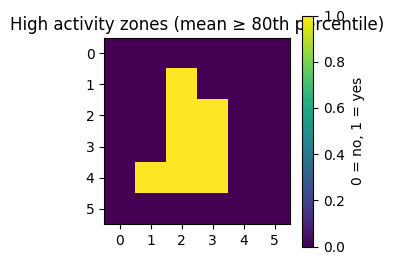

mean_p80 = 9.320216
dynamic_mask:
 [[0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 1 0 0]
 [0 1 1 1 0 0]
 [0 0 0 0 0 0]]


In [25]:
mean_p80 = np.percentile(mean_grid, 80)
dynamic_mask = mean_grid >= mean_p80

plt.figure(figsize=(3, 3))
plt.imshow(dynamic_mask.astype(int), vmin=0, vmax=1)
plt.title("High activity zones (mean ≥ 80th percentile)")
plt.xticks(range(6))
plt.yticks(range(6))
plt.colorbar(label="0 = no, 1 = yes")
plt.show()

print("mean_p80 =", mean_p80)
print("dynamic_mask:\n", dynamic_mask.astype(int))

# Detect High-Activity Regions

Identify the cells whose average motion belongs to the top 20%.

The resulting binary mask highlights the most dynamic screen regions.

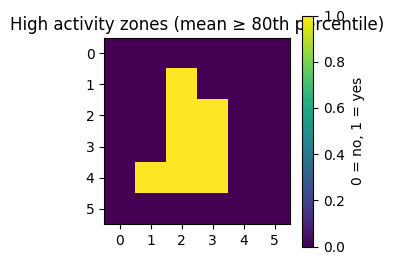

mean_p80 = 9.320216
dynamic_mask:
 [[0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 1 0 0]
 [0 1 1 1 0 0]
 [0 0 0 0 0 0]]


In [26]:
mean_p80 = np.percentile(mean_grid, 80)
dynamic_mask = mean_grid >= mean_p80

plt.figure(figsize=(3, 3))
plt.imshow(dynamic_mask.astype(int), vmin=0, vmax=1)
plt.title("High activity zones (mean ≥ 80th percentile)")
plt.xticks(range(6))
plt.yticks(range(6))
plt.colorbar(label="0 = no, 1 = yes")
plt.show()

print("mean_p80 =", mean_p80)
print("dynamic_mask:\n", dynamic_mask.astype(int))

# Detect Stable Regions

Select the 20% of grid cells with the lowest coefficient of variation.

These regions represent the most temporally stable parts of the slot interface and are considered potential anchor areas.

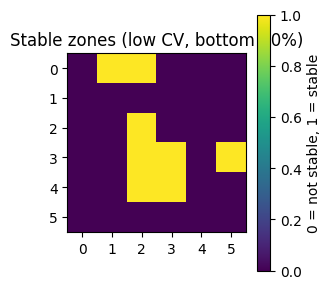

cv_p20 = 0.02588602
stable_mask:
 [[0 1 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 1 1 0 1]
 [0 0 1 1 0 0]
 [0 0 0 0 0 0]]


In [27]:
cv_p20 = np.percentile(cv_grid, 20)
stable_mask = cv_grid <= cv_p20

plt.figure(figsize=(3, 3))
plt.imshow(stable_mask.astype(int), vmin=0, vmax=1)
plt.title("Stable zones (low CV, bottom 20%)")
plt.xticks(range(6))
plt.yticks(range(6))
plt.colorbar(label="0 = not stable, 1 = stable", pad=0.05)
plt.tight_layout()
plt.show()

print("cv_p20 =", cv_p20)
print("stable_mask:\n", stable_mask.astype(int))

# Detect Anchor Candidates

Combine active regions with stable regions to identify anchor candidates.

A cell is considered an anchor candidate if it belongs to a stable region and is located inside or adjacent to an active area.

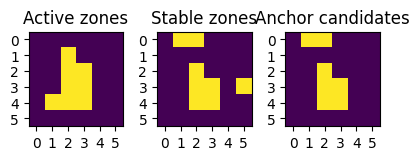

anchor_candidate_mask:
 [[0 1 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 0 0]]


In [32]:
kernel = np.ones((3, 3), dtype=int)
neighbor_active = convolve2d(active_mask.astype(int), kernel, mode="same") > 0

anchor_candidate_mask = stable_mask & neighbor_active

plt.figure(figsize=(4, 3))
for i, (m, t) in enumerate([
    (active_mask, "Active zones"),
    (stable_mask, "Stable zones"),
    (anchor_candidate_mask, "Anchor candidates"),
]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(m.astype(int), vmin=0, vmax=1)
    plt.title(t)
    plt.xticks(range(6))
    plt.yticks(range(6))
plt.tight_layout()
plt.show()

print("anchor_candidate_mask:\n", anchor_candidate_mask.astype(int))

# Visualize Anchor Candidates on the Original Frame

Overlay the detected anchor candidate cells on the original video frame.

This visualization helps verify that the detected regions correspond to meaningful interface elements.

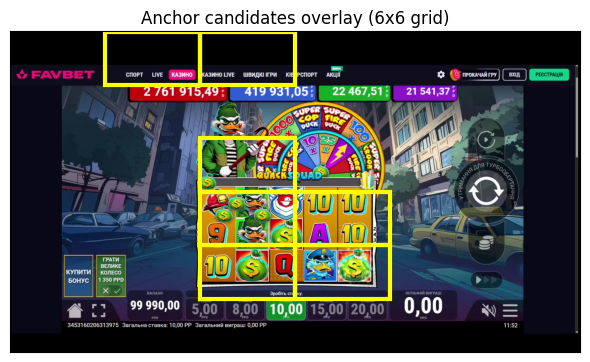

In [33]:
video_path = "../data/videos/video_id (2).mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

H, W = frame_rgb.shape[:2]
cell_h, cell_w = H / 6, W / 6

# рисуем
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(frame_rgb)
ax.set_title("Anchor candidates overlay (6x6 grid)")
ax.set_xticks([])
ax.set_yticks([])

for i in range(6):
    for j in range(6):
        if anchor_candidate_mask[i, j]:
            ax.add_patch(
                Rectangle(
                    (j * cell_w, i * cell_h),
                    cell_w,
                    cell_h,
                    fill=False,
                    edgecolor="yellow",
                    linewidth=3
                )
            )

plt.tight_layout()
plt.show()


# Compare Activity and Stability

Plot each grid cell using its average activity (Mean) and temporal variability (CV).

Active cells, stable cells, and anchor candidates are highlighted to illustrate how the selection criteria separate different regions of the interface.

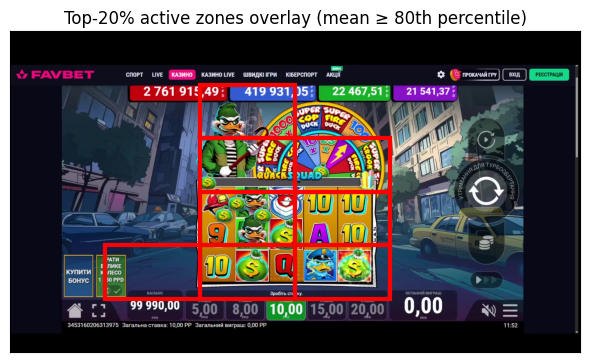

p80 (mean threshold) = 9.320216
active_mask:
 [[0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 1 1 0 0]
 [0 0 1 1 0 0]
 [0 1 1 1 0 0]
 [0 0 0 0 0 0]]


In [30]:
video_path = "../data/videos/video_id (2).mp4"
cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
H, W = frame_rgb.shape[:2]
cell_h, cell_w = H / 6, W / 6

mean_grid = grid_avg
p80 = np.percentile(mean_grid, 80)
active_mask = mean_grid >= p80

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(frame_rgb)
ax.set_title("Top-20% active zones overlay (mean ≥ 80th percentile)")
ax.set_xticks([]); ax.set_yticks([])

for i in range(6):
    for j in range(6):
        if active_mask[i, j]:
            ax.add_patch(
                Rectangle(
                    (j * cell_w, i * cell_h),
                    cell_w, cell_h,
                    fill=False,
                    edgecolor="red",
                    linewidth=3
                )
            )

plt.tight_layout()
plt.show()

print("p80 (mean threshold) =", p80)
print("active_mask:\n", active_mask.astype(int))

# Compare Different Videos

Apply the same anchor detection pipeline to two different slot recordings.

This comparison demonstrates that the method consistently identifies active and stable regions across different games.

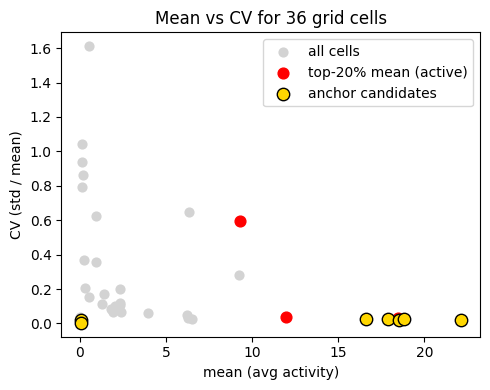

In [34]:
mean_grid = grid_avg
std_grid  = grid_means
cv_grid   = std_grid / (mean_grid + 1e-6)

p80 = np.percentile(mean_grid, 80)
active_mask = mean_grid >= p80

mean_flat   = mean_grid.flatten()
cv_flat     = cv_grid.flatten()
active_flat = active_mask.flatten()
anchor_flat = anchor_candidate_mask.flatten()

plt.figure(figsize=(5, 4))

plt.scatter(
    mean_flat,
    cv_flat,
    color="lightgray",
    s=40,
    label="all cells"
)

plt.scatter(
    mean_flat[active_flat],
    cv_flat[active_flat],
    color="red",
    s=60,
    label="top-20% mean (active)"
)

plt.scatter(
    mean_flat[anchor_flat],
    cv_flat[anchor_flat],
    color="gold",
    s=80,
    edgecolor="black",
    label="anchor candidates"
)

plt.xlabel("mean (avg activity)")
plt.ylabel("CV (std / mean)")
plt.title("Mean vs CV for 36 grid cells")
plt.legend()
plt.tight_layout()
plt.show()

# Create a Reusable Processing Function

Encapsulate the complete motion analysis into a reusable function.

The function computes the mean motion, standard deviation, and frame count for any input video.

In [35]:
def grid_mean_std_for_video(video_path, grid=6, skip_start_frames=100):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    step = int(round(fps)) if fps and fps > 0 else 30  

    ret, first = cap.read()
    if not ret:
        cap.release()
        raise ValueError(f"Failed to read the first frame: {video_path}")

    for _ in range(skip_start_frames):
        if not cap.grab():
            break

    ret, prev_frame = cap.read()
    if not ret:
        cap.release()
        raise ValueError(f"Failed to read the frame after skipping: {video_path}")

    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

    h, w = prev_gray.shape
    cell_h = h // grid
    cell_w = w // grid

    grid_sum = np.zeros((grid, grid), dtype=np.float64)
    grid_sum_sq = np.zeros((grid, grid), dtype=np.float64)
    count = 0

    while True:
        ok = True
        for _ in range(step - 1):
            if not cap.grab():
                ok = False
                break
        if not ok:
            break

        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(gray, prev_gray).astype(np.float32)

        grid_vals = np.zeros((grid, grid), dtype=np.float32)
        for i in range(grid):
            for j in range(grid):
                y0, y1 = i * cell_h, (i + 1) * cell_h
                x0, x1 = j * cell_w, (j + 1) * cell_w
                grid_vals[i, j] = diff[y0:y1, x0:x1].mean()

        grid_sum += grid_vals
        grid_sum_sq += grid_vals ** 2
        count += 1
        prev_gray = gray

    cap.release()

    denom = max(count, 1)
    mean_grid = (grid_sum / denom).astype(np.float32)
    var_grid = (grid_sum_sq / denom) - (mean_grid.astype(np.float64) ** 2)
    var_grid = np.maximum(var_grid, 0.0)  
    std_grid = np.sqrt(var_grid).astype(np.float32)

    return mean_grid, std_grid, count

# Apply the Function to Multiple Videos

Run the reusable function on two different recordings and visualize the detected active regions and anchor candidates.

This serves as a qualitative validation of the proposed method.

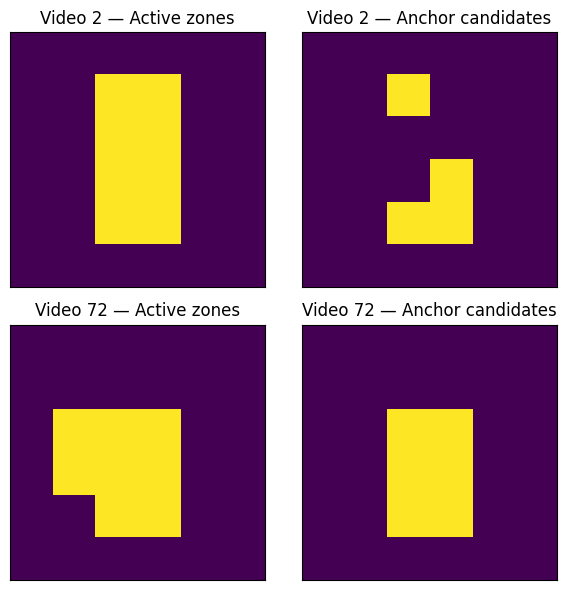

In [ ]:
video2_path  = "../data/videos/video_id (2).mp4"
video72_path = "../data/videos/video_id (72).mp4"

mean_2, std_2, _  = grid_mean_std_for_video(video2_path)
mean_72, std_72, _ = grid_mean_std_for_video(video72_path)

cv_2  = std_2  / (mean_2  + 1e-6)
cv_72 = std_72 / (mean_72 + 1e-6)

active_2  = mean_2  >= np.percentile(mean_2, 80)
active_72 = mean_72 >= np.percentile(mean_72, 80)

stable_2  = cv_2  <= np.percentile(cv_2, 20)
stable_72 = cv_72 <= np.percentile(cv_72, 20)

anchor_2  = active_2  & stable_2
anchor_72 = active_72 & stable_72

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0,0].imshow(active_2.astype(int))
axes[0,0].set_title("Video 2 — Active zones")

axes[0,1].imshow(anchor_2.astype(int))
axes[0,1].set_title("Video 2 — Anchor candidates")

axes[1,0].imshow(active_72.astype(int))
axes[1,0].set_title("Video 72 — Active zones")

axes[1,1].imshow(anchor_72.astype(int))
axes[1,1].set_title("Video 72 — Anchor candidates")

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Variant B Pipeline Specification

Summarize the complete processing pipeline.

This specification describes the input, preprocessing, statistical computations, threshold selection, and generated output masks used throughout Variant B.

In [36]:
variant_b_spec = {
    "input": {
        "video_duration_sec": "~38-42",
        "audio": "ignored"
    },
    "sampling": {
        "step": "~1 sec (based on FPS)",
        "skip_start_frames": 100
    },
    "diff": {
        "space": "grayscale",
        "metric": "absdiff(frame_t, frame_t-1)"
    },
    "grid": {
        "size": "6x6",
        "cell_agg": "mean(diff pixels inside cell)"
    },
    "stats_per_cell": {
        "mean": "avg over time",
        "std": "std over time",
        "cv": "std / (mean + eps), eps=1e-6"
    },
    "thresholds": {
        "active": "mean >= 80th percentile (top 20%)",
        "stable": "cv <= 20th percentile (bottom 20%)"
    },
    "output_masks": [
        "active_mask (6x6, bool)",
        "stable_mask (6x6, bool)",
        "anchor_candidate_mask (6x6, bool)"
    ]
}

for k, v in variant_b_spec.items():
    print(f"\n{k.upper()}:")
    if isinstance(v, dict):
        for kk, vv in v.items():
            print(f"  - {kk}: {vv}")
    else:
        for item in v:
            print(f"  - {item}")


INPUT:
  - video_duration_sec: ~38-42
  - audio: ignored

SAMPLING:
  - step: ~1 sec (based on FPS)
  - skip_start_frames: 100

DIFF:
  - space: grayscale
  - metric: absdiff(frame_t, frame_t-1)

GRID:
  - size: 6x6
  - cell_agg: mean(diff pixels inside cell)

STATS_PER_CELL:
  - mean: avg over time
  - std: std over time
  - cv: std / (mean + eps), eps=1e-6

THRESHOLDS:
  - active: mean >= 80th percentile (top 20%)
  - stable: cv <= 20th percentile (bottom 20%)

OUTPUT_MASKS:
  - active_mask (6x6, bool)
  - stable_mask (6x6, bool)
  - anchor_candidate_mask (6x6, bool)


# Store Intermediate Results

Save all intermediate computations into a single dictionary.

Keeping all outputs together makes further analysis, visualization, and debugging much easier.

In [37]:
video_id = 2
video_path = f"../data/videos/video_id ({video_id}).mp4"

mean_grid, std_grid, count = grid_mean_std_for_video(video_path)
cv_grid = std_grid / (mean_grid + 1e-6)

p80_mean = np.percentile(mean_grid, 80)
p20_cv   = np.percentile(cv_grid, 20)

active_mask = mean_grid >= p80_mean
stable_mask = cv_grid <= p20_cv
anchor_mask = active_mask & stable_mask

result = {
    "video_id": video_id,
    "video_path": video_path,
    "count_steps": int(count),
    "thresholds": {"mean_p80": float(p80_mean), "cv_p20": float(p20_cv)},
    "mean_grid": mean_grid,
    "cv_grid": cv_grid,
    "active_mask": active_mask,
    "stable_mask": stable_mask,
    "anchor_mask": anchor_mask
}

print("Saved result keys:", list(result.keys()))
print("count_steps:", result["count_steps"])
print("thresholds:", result["thresholds"])
print("anchor_mask:\n", result["anchor_mask"].astype(int))

Saved result keys: ['video_id', 'video_path', 'count_steps', 'thresholds', 'mean_grid', 'cv_grid', 'active_mask', 'stable_mask', 'anchor_mask']
count_steps: 42
thresholds: {'mean_p80': 15.149565696716309, 'cv_p20': 0.6228413581848145}
anchor_mask:
 [[0 0 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 1 0 0]
 [0 0 1 1 0 0]
 [0 0 0 0 0 0]]


# Build Video-Level Feature Extraction

Create a reusable function that extracts numerical features from a single video.

These features summarize activity, temporal stability, and anchor regions, providing a compact representation for later comparison.

In [38]:
def variant_b_features(video_id):
    video_path = f"../data/videos/video_id ({video_id}).mp4"

    mean_grid, std_grid, count = grid_mean_std_for_video(video_path)
    cv_grid = std_grid / (mean_grid + 1e-6)

    mean_p80 = float(np.percentile(mean_grid, 80))
    cv_p20   = float(np.percentile(cv_grid, 20))

    active_mask = mean_grid >= mean_p80
    stable_mask = cv_grid <= cv_p20
    anchor_mask = active_mask & stable_mask

    features = {
        "video_id": int(video_id),
        "count_steps": int(count),
        "mean_p80": mean_p80,
        "cv_p20": cv_p20,
        "active_cells": int(active_mask.sum()),
        "anchor_cells": int(anchor_mask.sum()),
        "mean_of_mean": float(mean_grid.mean()),
        "mean_of_cv": float(cv_grid.mean()),
    }
    return features

features_list = []
for vid in range(1, 6):  
    features_list.append(variant_b_features(vid))

features_list

[{'video_id': 1,
  'count_steps': 38,
  'mean_p80': 9.657591819763184,
  'cv_p20': 0.6266958117485046,
  'active_cells': 8,
  'anchor_cells': 3,
  'mean_of_mean': 5.553946495056152,
  'mean_of_cv': 0.9339603781700134},
 {'video_id': 2,
  'count_steps': 42,
  'mean_p80': 15.149565696716309,
  'cv_p20': 0.6228413581848145,
  'active_cells': 8,
  'anchor_cells': 4,
  'mean_of_mean': 5.867290496826172,
  'mean_of_cv': 1.0735732316970825},
 {'video_id': 3,
  'count_steps': 42,
  'mean_p80': 15.12125015258789,
  'cv_p20': 0.6470043659210205,
  'active_cells': 8,
  'anchor_cells': 4,
  'mean_of_mean': 7.37867546081543,
  'mean_of_cv': 0.8577481508255005},
 {'video_id': 4,
  'count_steps': 41,
  'mean_p80': 21.677406311035156,
  'cv_p20': 0.2844845652580261,
  'active_cells': 8,
  'anchor_cells': 5,
  'mean_of_mean': 9.794514656066895,
  'mean_of_cv': 0.6390244960784912},
 {'video_id': 5,
  'count_steps': 43,
  'mean_p80': 22.1462345123291,
  'cv_p20': 0.5688831806182861,
  'active_cells': 8,


# Compare All Videos

Extract the same set of features from every recording and combine them into a single table.

This enables ranking, comparison, and identification of videos with different motion characteristics.

In [39]:
all_features = []
for vid in range(1, 82):  
    all_features.append(variant_b_features(vid))

df = pd.DataFrame(all_features)

df_sorted = df.sort_values(["anchor_cells", "mean_of_cv"], ascending=[False, True])
df_sorted.head(10)

,video_id,count_steps,mean_p80,cv_p20,active_cells,anchor_cells,mean_of_mean,mean_of_cv
76,77,40,6.952694,0.436456,8,8,5.754424,0.796298
63,64,37,24.130428,0.569972,8,8,10.094441,1.037122
64,65,37,23.192003,0.540629,8,7,10.648922,0.716735
59,60,40,21.037743,0.599997,8,7,9.831625,0.856574
74,75,39,15.460337,0.676921,8,7,7.180666,0.906785
73,74,38,3.383688,0.502662,8,7,2.876310,0.943799
42,43,39,17.558222,0.475612,8,6,9.163471,0.733068
57,58,37,18.079189,0.445738,8,6,7.997817,0.735210
69,70,38,1.742900,0.675273,8,6,4.653732,0.792914
71,72,39,13.297232,0.399543,8,6,8.792758,0.796857


# Display Representative Videos

Visualize representative examples with maximum anchor cells,
minimum anchor cells, and maximum temporal variability.

These examples illustrate the range of dynamic composition patterns.

In [40]:
vid_max_anchor = df.sort_values("anchor_cells", ascending=False).iloc[0]["video_id"]

vid_min_anchor = df.sort_values("anchor_cells", ascending=True).iloc[0]["video_id"]

vid_max_cv = df.sort_values("mean_of_cv", ascending=False).iloc[0]["video_id"]

vid_max_anchor, vid_min_anchor, vid_max_cv

(np.float64(77.0), np.float64(8.0), np.float64(32.0))

# Visualize Dynamic Composition Space

Plot every video using spatial coherence (anchor_cells)
and temporal variability (mean_of_cv).

This reveals the overall distribution of videos in the feature space.

In [41]:
def show_anchor_overlay(video_id):
    video_path = f"../data/videos/video_id ({video_id}).mp4"

    mean_grid, std_grid, _ = grid_mean_std_for_video(video_path)
    cv_grid = std_grid / (mean_grid + 1e-6)

    active = mean_grid >= np.percentile(mean_grid, 80)
    stable = cv_grid <= np.percentile(cv_grid, 20)
    anchor = active & stable

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    H, W = frame_rgb.shape[:2]
    cell_h, cell_w = H / 6, W / 6

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(frame_rgb)
    ax.set_title(f"Video {video_id} — Anchor candidates")
    ax.set_xticks([])
    ax.set_yticks([])

    for i in range(6):
        for j in range(6):
            if anchor[i, j]:
                ax.add_patch(
                    Rectangle(
                        (j * cell_w, i * cell_h),
                        cell_w,
                        cell_h,
                        fill=False,
                        edgecolor="yellow",
                        linewidth=3
                    )
                )

    plt.tight_layout()
    plt.show()

# Cluster Dynamic Composition Patterns

Apply K-Means clustering to group videos with similar
spatial and temporal behavior.

The discovered groups provide an unsupervised categorization
of dynamic composition styles.

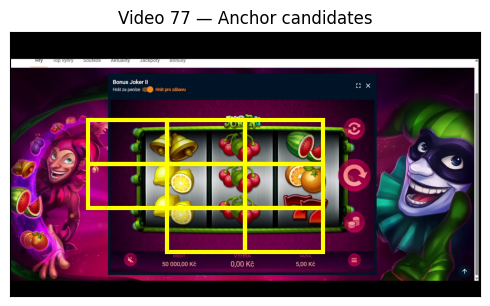

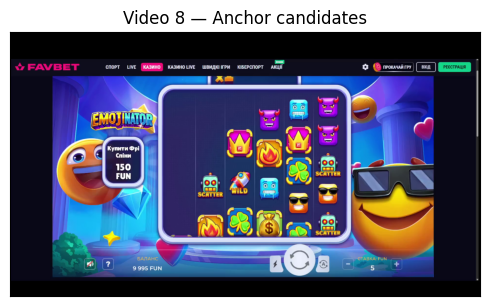

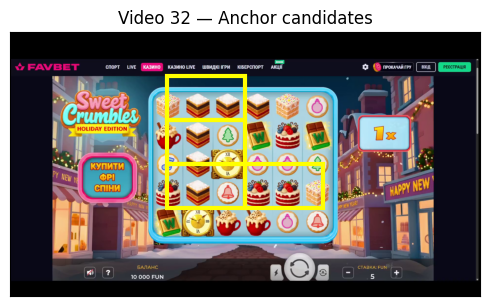

In [42]:
show_anchor_overlay(int(vid_max_anchor))
show_anchor_overlay(int(vid_min_anchor))
show_anchor_overlay(int(vid_max_cv))

# Analyze Cluster Statistics

Compute summary statistics for every cluster.

Comparing cluster averages helps interpret the behavioral
differences between discovered composition patterns.

In [43]:
def show_anchor_overlay(video_id):
    video_path = f"../data/videos/video_id ({video_id}).mp4"

    mean_grid, std_grid, _ = grid_mean_std_for_video(video_path)
    cv_grid = std_grid / (mean_grid + 1e-6)

    active = mean_grid >= np.percentile(mean_grid, 80)
    stable = cv_grid <= np.percentile(cv_grid, 20)
    anchor = active & stable

    print(f"Video {video_id}: anchor_cells =", int(anchor.sum()))

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    H, W = frame_rgb.shape[:2]
    cell_h, cell_w = H / 6, W / 6

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(frame_rgb)
    ax.set_title(f"Video {video_id} — Anchor candidates")
    ax.set_xticks([]); ax.set_yticks([])

    for i in range(6):
        for j in range(6):
            if anchor[i, j]:
                ax.add_patch(Rectangle((j*cell_w, i*cell_h), cell_w, cell_h,
                                       fill=False, edgecolor="yellow", linewidth=3))
    plt.tight_layout()
    plt.show()

# Interpret Cluster Roles

Automatically assign semantic labels to the discovered clusters
based on their statistical characteristics.

This converts anonymous cluster IDs into interpretable
behavioral categories.

In [44]:
print("anchor_cells min:", df["anchor_cells"].min())
print("anchor_cells max:", df["anchor_cells"].max())
df["anchor_cells"].value_counts().sort_index()

anchor_cells min: 0
anchor_cells max: 8


anchor_cells
0     7
1     6
2    10
3    16
4    17
5     9
6    10
7     4
8     2
Name: count, dtype: int64

# Visualize Dynamic Composition Space

Plot all 81 videos in a two-dimensional feature space using:

- `anchor_cells` — the number of spatially coherent and stable screen regions;
- `mean_of_cv` — the average temporal variability across the screen grid.

Each point represents one video. The plot helps reveal the overall distribution of dynamic composition patterns before clustering.

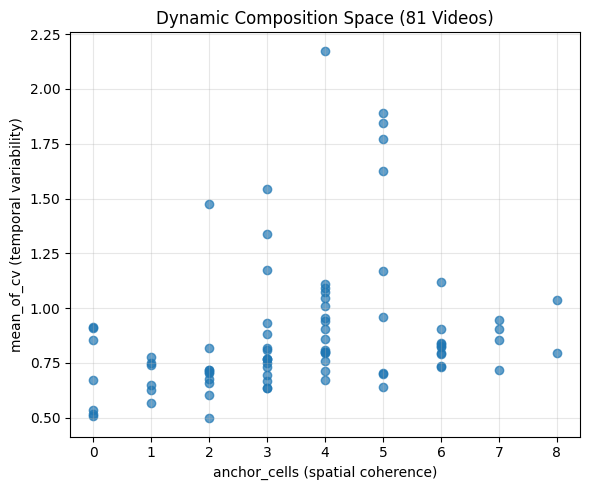

In [45]:
plt.figure(figsize=(6, 5))

plt.scatter(
    df["anchor_cells"],
    df["mean_of_cv"],
    alpha=0.7
)

plt.xlabel("anchor_cells (spatial coherence)")
plt.ylabel("mean_of_cv (temporal variability)")
plt.title("Dynamic Composition Space (81 Videos)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cluster Dynamic Composition Patterns

Standardize the selected dynamic features and apply K-Means clustering with three clusters.

The model groups videos according to similarities in:

- spatial coherence represented by `anchor_cells`;
- temporal variability represented by `mean_of_cv`.

The resulting colors show an unsupervised separation of the videos into three dynamic composition patterns.

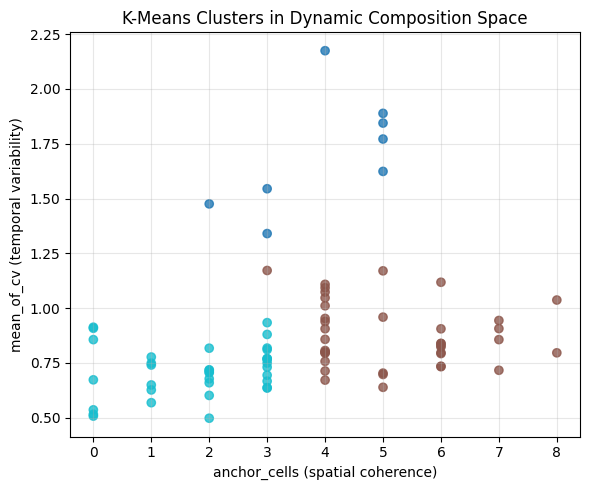

In [46]:
X = df[["anchor_cells", "mean_of_cv"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    df["anchor_cells"],
    df["mean_of_cv"],
    c=df["cluster"],
    cmap="tab10",
    alpha=0.8
)

plt.xlabel("anchor_cells (spatial coherence)")
plt.ylabel("mean_of_cv (temporal variability)")
plt.title("K-Means Clusters in Dynamic Composition Space")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare Average Cluster Characteristics

Calculate the average values of the main dynamic features for every cluster.

This provides a first summary of how the discovered groups differ in:

- number of anchor cells;
- temporal variability;
- overall amount of motion.

The cluster averages help assign an initial behavioral meaning to each group.

In [47]:
df.groupby("cluster")[["anchor_cells", "mean_of_cv", "mean_of_mean"]].mean()

,anchor_cells,mean_of_cv,mean_of_mean
cluster,,,
0,4.000000,1.707920,9.733071
1,5.157895,0.877429,9.139099
2,1.800000,0.714053,11.562294


# Analyze Detailed Cluster Statistics

Calculate the mean, minimum, and maximum values of the main features inside every cluster.

This extended summary shows both the typical behavior and the range of variation within each discovered group.

The results help verify whether the clusters are clearly separated or still overlap.

In [48]:
cols = ["anchor_cells", "mean_of_cv", "mean_of_mean"]
cluster_stats = df.groupby("cluster")[cols].agg(["mean", "min", "max"]).round(3)
cluster_stats

anchor_cells         mean_of_cv               mean_of_mean         \
                mean min max       mean    min    max         mean    min   
cluster                                                                     
0              4.000   2   5      1.708  1.340  2.174        9.733  3.958   
1              5.158   3   8      0.877  0.639  1.172        9.139  2.876   
2              1.800   0   3      0.714  0.498  0.934       11.562  3.826   

                 
            max  
cluster          
0        13.877  
1        18.493  
2        20.841

# Interpret Cluster Roles

Assign interpretable behavioral names to the anonymous K-Means cluster IDs.

The cluster with the lowest average number of anchor cells is interpreted as fragmented.

Among the remaining clusters:

- the cluster with higher temporal variability is interpreted as event-driven;
- the remaining cluster is interpreted as rhythmic.

The code also calculates approximate thresholds that separate these behavioral patterns.

In [49]:
mean_anchor_by_cluster = df.groupby("cluster")["anchor_cells"].mean()
frag_cluster = int(mean_anchor_by_cluster.idxmin())

other = df[df["cluster"] != frag_cluster]
mean_cv_by_cluster = other.groupby("cluster")["mean_of_cv"].mean()
event_cluster = int(mean_cv_by_cluster.idxmax())

rhyth_cluster = int([c for c in df["cluster"].unique() if c not in [frag_cluster, event_cluster]][0])

t_anchor = 0.5 * (df[df["cluster"] == frag_cluster]["anchor_cells"].max() +
                  df[df["cluster"] != frag_cluster]["anchor_cells"].min())

t_cv = 0.5 * (df[df["cluster"] == rhyth_cluster]["mean_of_cv"].max() +
              df[df["cluster"] == event_cluster]["mean_of_cv"].min())

print("Cluster mapping:")
print("  fragmented:", frag_cluster)
print("  rhythmic  :", rhyth_cluster)
print("  event     :", event_cluster)

print("\nThresholds:")
print("  t_anchor (fragmented vs others) =", round(float(t_anchor), 3))
print("  t_cv (rhythmic vs event)        =", round(float(t_cv), 3))

Cluster mapping:
  fragmented: 2
  rhythmic  : 1
  event     : 0

Thresholds:
  t_anchor (fragmented vs others) = 2.5
  t_cv (rhythmic vs event)        = 1.256
